# Electricity consumption EDA: 2021–2024

This notebook evaluates the training data before modeling. It covers:

- coverage, schema, missingness, duplicates, and series completeness;
- UTC/local-time and Danish daylight-saving-time behavior;
- trends by month, year, region, consumer category, hour, and weekday;
- distributions, outliers, and unusual observations;
- modeling risks, temporal splitting, and leakage prevention.

The processed file currently contains the replacement-character label `Region Sj�lland`. This notebook repairs that label for analysis and validates the result. The same repair should also be applied upstream in `src/preprocessing/build_eda_dataset.py`.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

EXPECTED_REGIONS = {
    'Region Hovedstaden',
    'Region Midtjylland',
    'Region Nordjylland',
    'Region Sjælland',
    'Region Syddanmark',
}
EXPECTED_CATEGORY3 = {'Erhverv', 'Offentlige foretagender', 'Privat'}
EXPECTED_CATEGORY2 = {'Erhverv', 'Privat'}

## 1. Load data reproducibly

The path is resolved from the notebook location when possible, so execution does not depend on the current working directory.

In [3]:
NOTEBOOK_DIR = Path.cwd()
candidate_roots = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
PROJECT_ROOT = next(root for root in candidate_roots if (root / 'data' / 'raw').exists())
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
raw_files = [
    RAW_DATA_DIR / f'consumption_{year}_{month:02d}.parquet'
    for year in range(2021, 2026)
    for month in range(1, 13)
]
missing_files = [file.name for file in raw_files if not file.exists()]
if missing_files:
    raise FileNotFoundError('Missing monthly raw files: ' + ', '.join(missing_files))
    raise FileNotFoundError('Could not find the processed 2021–2024 parquet file.')

df = pd.concat([pd.read_parquet(file) for file in raw_files], ignore_index=True)
print(f'Loaded {len(raw_files)} monthly raw files from: {RAW_DATA_DIR}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())

Loaded 60 monthly raw files from: c:\TUYET\GIT_REPO\Danish-Energy-Intelligence\data\raw
Shape: 657,360 rows × 6 columns


,TimeUTC,TimeDK,RegionName,ConsumerCategory3,ConsumerCategory2,ConsumptionkWh
0,2021-01-31T22:00:00,2021-01-31T23:00:00,Region Hovedstaden,Erhverv,Erhverv,"501,585.00"
1,2021-01-31T22:00:00,2021-01-31T23:00:00,Region Hovedstaden,Offentlige foretagender,Erhverv,"84,791.73"
2,2021-01-31T22:00:00,2021-01-31T23:00:00,Region Hovedstaden,Privat,Privat,"326,565.03"
3,2021-01-31T22:00:00,2021-01-31T23:00:00,Region Midtjylland,Erhverv,Erhverv,"518,935.39"
4,2021-01-31T22:00:00,2021-01-31T23:00:00,Region Midtjylland,Offentlige foretagender,Erhverv,"52,216.77"


## 2. Clean labels and establish the data contract

`TimeUTC` is the canonical timestamp for continuity and modeling. `TimeDK` is retained for Danish calendar features and local-time visualizations.

In [4]:
# Repair the current replacement-character encoding issue.
df['RegionName'] = df['RegionName'].replace({'Region Sj�lland': 'Region Sjælland'})
df['TimeUTC'] = pd.to_datetime(df['TimeUTC'])
df['TimeDK'] = pd.to_datetime(df['TimeDK'])

# Rebuild calendar fields from the validated local timestamp.
df['date'] = df['TimeDK'].dt.date
df['year'] = df['TimeDK'].dt.year
df['month'] = df['TimeDK'].dt.month
df['month_name'] = df['TimeDK'].dt.month_name()
df['day_of_week'] = df['TimeDK'].dt.dayofweek
df['day_name'] = df['TimeDK'].dt.day_name()
df['hour'] = df['TimeDK'].dt.hour
df['is_weekend'] = df['day_of_week'] >= 5

print('Time range UTC:', df['TimeUTC'].min(), 'to', df['TimeUTC'].max())
print('Time range DK :', df['TimeDK'].min(), 'to', df['TimeDK'].max())
print('Regions:', sorted(df['RegionName'].unique()))
print('Category 3:', sorted(df['ConsumerCategory3'].unique()))
print('Category 2:', sorted(df['ConsumerCategory2'].unique()))

assert set(df['RegionName'].unique()) == EXPECTED_REGIONS
assert set(df['ConsumerCategory3'].unique()) == EXPECTED_CATEGORY3
assert set(df['ConsumerCategory2'].unique()) == EXPECTED_CATEGORY2
assert df['ConsumptionkWh'].ge(0).all()
print('Data-contract checks passed.')

Time range UTC: 2020-12-31 23:00:00 to 2025-12-31 22:00:00
Time range DK : 2021-01-01 00:00:00 to 2025-12-31 23:00:00
Regions: ['Region Hovedstaden', 'Region Midtjylland', 'Region Nordjylland', 'Region Sjælland', 'Region Syddanmark']
Category 3: ['Erhverv', 'Offentlige foretagender', 'Privat']
Category 2: ['Erhverv', 'Privat']
Data-contract checks passed.


In [5]:
print('Missing values:')
display(df.isna().sum().to_frame('missing').query('missing > 0'))

key = ['TimeUTC', 'RegionName', 'ConsumerCategory3', 'ConsumerCategory2']
print('Duplicate modeling keys:', df.duplicated(key).sum())
print('Duplicate complete rows:', df.duplicated().sum())
print('Rows per region/category series:')
display(df.groupby(['RegionName', 'ConsumerCategory3']).size().describe().to_frame('rows'))

assert not df.isna().any().any()
assert df.duplicated(key).sum() == 0

Missing values:


,missing


Duplicate modeling keys: 0
Duplicate complete rows: 0
Rows per region/category series:


,rows
count,15.00
mean,"43,824.00"
std,0.00
min,"43,824.00"
25%,"43,824.00"
50%,"43,824.00"
75%,"43,824.00"
max,"43,824.00"


## 3. Coverage, continuity, and daylight saving time

There should be one observation per hour in UTC for each region/category series. Local Danish time has 23 hours on the spring transition day and 25 on the autumn transition day; that is expected, but local timestamps are ambiguous during the repeated hour.

In [6]:
series_key = ['RegionName', 'ConsumerCategory3']
utc_diff = (
    df.sort_values(series_key + ['TimeUTC'])
      .groupby(series_key)['TimeUTC']
      .diff()
      .dt.total_seconds()
)
print('Non-hourly UTC gaps:', (utc_diff.dropna() != 3600).sum())
print('Per-series row counts:')
display(df.groupby(series_key).size().rename('rows').to_frame())

local_duplicates_all_years = df.duplicated(series_key + ['TimeDK']).sum()
local_duplicates = df.loc[df['year'] <= 2024].duplicated(series_key + ['TimeDK']).sum()
print('Duplicate local timestamps (all years):', local_duplicates_all_years)
daily_counts = df.groupby('date').size() if 'date' in df else df.assign(date=df['TimeDK'].dt.date).groupby('date').size()
print('Daily row-count extremes:')
display(pd.concat([daily_counts.nsmallest(5), daily_counts.nlargest(5)]))

assert (utc_diff.dropna() == 3600).all()
assert local_duplicates_all_years == 75  # 15 series × one repeated local hour in autumn for five years
assert local_duplicates == 60  # 15 series × one repeated local hour in autumn

Non-hourly UTC gaps: 0
Per-series row counts:


rows
RegionName         ConsumerCategory3             
Region Hovedstaden Erhverv                  43824
                   Offentlige foretagender  43824
                   Privat                   43824
Region Midtjylland Erhverv                  43824
                   Offentlige foretagender  43824
                   Privat                   43824
Region Nordjylland Erhverv                  43824
                   Offentlige foretagender  43824
                   Privat                   43824
Region Sjælland    Erhverv                  43824
                   Offentlige foretagender  43824
                   Privat                   43824
Region Syddanmark  Erhverv                  43824
                   Offentlige foretagender  43824
                   Privat                   43824

Duplicate local timestamps (all years): 75
Daily row-count extremes:


date
2021-03-28    345
2022-03-27    345
2023-03-26    345
2024-03-31    345
2025-03-30    345
2021-10-31    375
2022-10-30    375
2023-10-29    375
2024-10-27    375
2025-10-26    375
dtype: int64

In [7]:


coverage = (df.groupby(['year', 'month']).agg(
    rows=('TimeUTC', 'size'),
    first_utc=('TimeUTC', 'min'),
    last_utc=('TimeUTC', 'max'),
).reset_index())
display(coverage.pivot(index='month', columns='year', values='rows'))

year,2021,2022,2023,2024,2025
month,,,,,
1,11160,11160,11160,11160,11160
2,10080,10080,10080,10440,10080
3,11145,11145,11145,11145,11145
4,10800,10800,10800,10800,10800
5,11160,11160,11160,11160,11160
6,10800,10800,10800,10800,10800
7,11160,11160,11160,11160,11160
8,11160,11160,11160,11160,11160
9,10800,10800,10800,10800,10800


## 4. Overall time trends

Raw totals are useful for reporting, but comparisons should also account for the number of valid records in each period. The first chart shows total monthly consumption; the second divides each monthly total by the number of valid records, showing typical hourly load. Winter peaks and summer troughs indicate seasonality.

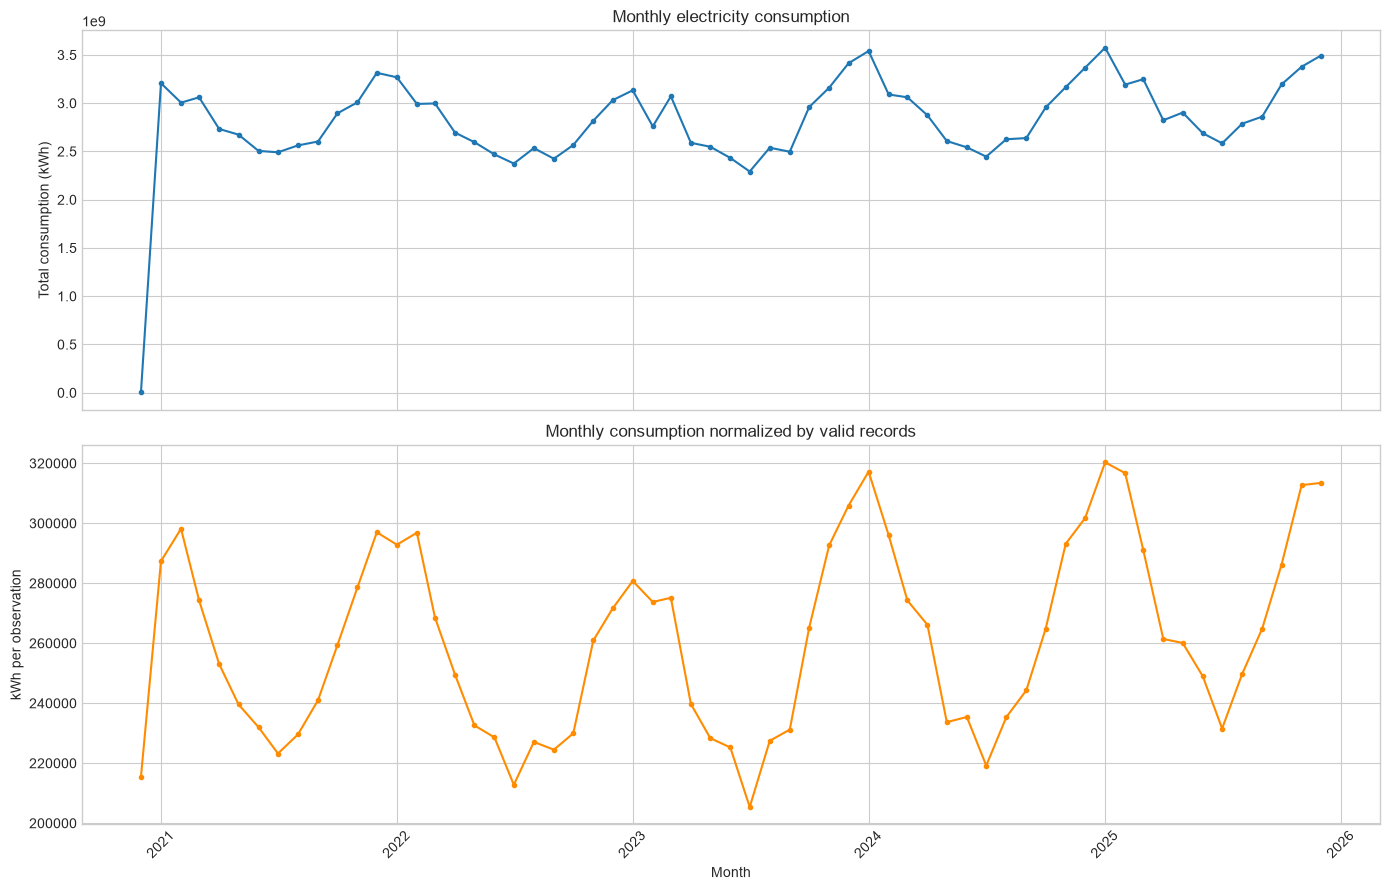

In [8]:
monthly = (df.groupby(df['TimeUTC'].dt.to_period('M'))['ConsumptionkWh']
              .agg(total_kwh='sum', valid_records='count')
              .reset_index(names='period'))
monthly['period'] = monthly['period'].dt.to_timestamp()
monthly['kwh_per_hour'] = monthly['total_kwh'] / monthly['valid_records']
monthly['year'] = monthly['period'].dt.year
monthly['month'] = monthly['period'].dt.month

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(monthly['period'], monthly['total_kwh'], marker='o', ms=3)
axes[0].set_title('Monthly electricity consumption')
axes[0].set_ylabel('Total consumption (kWh)')
axes[1].plot(monthly['period'], monthly['kwh_per_hour'], marker='o', ms=3, color='darkorange')
axes[1].set_title('Monthly consumption normalized by valid records')
axes[1].set_ylabel('kWh per observation')
axes[1].set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
annual = (df.groupby('year').agg(
    total_kwh=('ConsumptionkWh', 'sum'),
    valid_records=('ConsumptionkWh', 'size'),
).reset_index())
annual['kwh_per_observation'] = annual['total_kwh'] / annual['valid_records']
annual['yoy_total_pct'] = annual['total_kwh'].pct_change() * 100
annual['yoy_normalized_pct'] = annual['kwh_per_observation'].pct_change() * 100
display(annual)

,year,total_kwh,valid_records,kwh_per_observation,yoy_total_pct,yoy_normalized_pct
0,2021,"34,059,882,165.26",131400,"259,207.63",NaN,NaN
1,2022,"32,766,126,099.21",131400,"249,361.69",-3.80,-3.80
2,2023,"33,394,788,432.61",131400,"254,146.03",1.92,1.92
3,2024,"34,915,956,083.73",131760,"264,996.63",4.56,4.27
4,2025,"36,732,369,934.97",131400,"279,546.19",5.20,5.49


## 5. Seasonality across years

The normalized view helps distinguish seasonality from changes in the overall level of consumption.

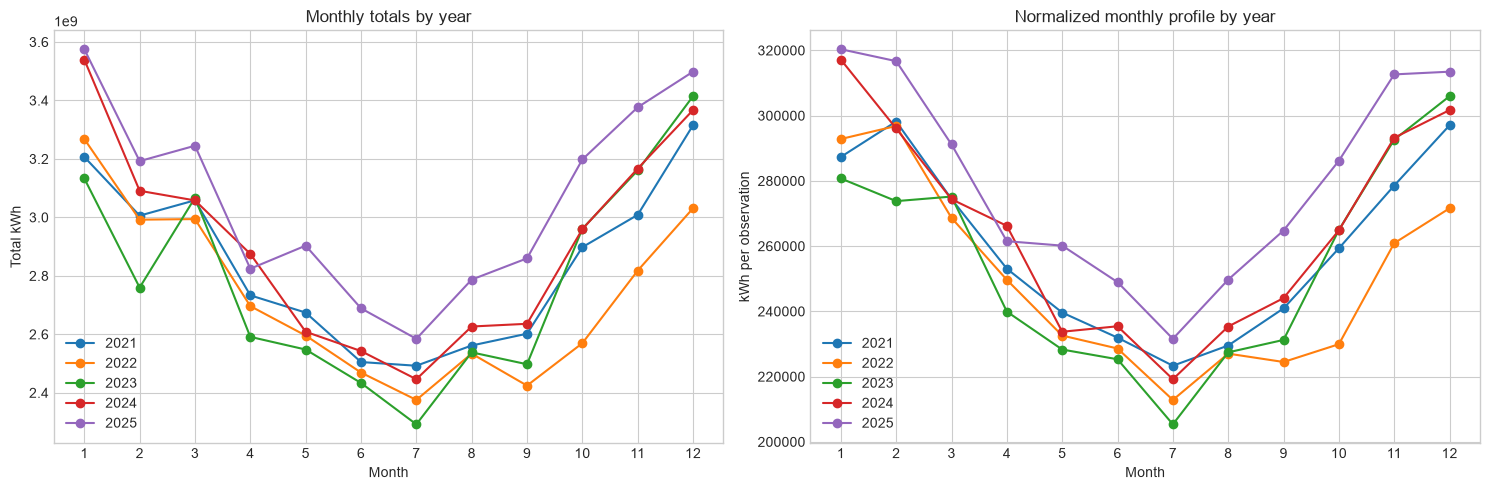

In [10]:
monthly_year = (df.groupby(['year', 'month']).agg(
    total_kwh=('ConsumptionkWh', 'sum'),
    valid_hours=('ConsumptionkWh', 'size'),
).reset_index())
monthly_year['kwh_per_hour'] = monthly_year['total_kwh'] / monthly_year['valid_hours']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for year, group in monthly_year.groupby('year'):
    axes[0].plot(group['month'], group['total_kwh'], marker='o', label=str(year))
    axes[1].plot(group['month'], group['kwh_per_hour'], marker='o', label=str(year))
for ax, title, ylabel in zip(axes, ['Monthly totals by year', 'Normalized monthly profile by year'], ['Total kWh', 'kWh per observation']):
    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Region and consumer-category breakdowns

Consumption by region and year


year,2021,2022,2023,2024,2025
RegionName,,,,,
Region Hovedstaden,"8,153,919,466.78","7,855,696,744.52","7,835,128,543.65","8,159,962,061.45","8,610,524,581.01"
Region Midtjylland,"8,313,733,907.38","7,988,611,202.70","8,398,460,441.94","8,704,781,658.02","8,989,976,944.91"
Region Nordjylland,"4,239,586,492.80","4,027,643,800.80","3,998,042,472.37","4,204,083,196.58","4,357,917,778.16"
Region Sjælland,"4,703,200,031.73","4,516,188,356.65","4,640,934,268.73","4,914,911,033.05","5,205,184,898.46"
Region Syddanmark,"8,649,442,266.56","8,377,985,994.54","8,522,222,705.92","8,932,218,134.63","9,568,765,732.43"


Consumption by category and year


year,2021,2022,2023,2024,2025
ConsumerCategory3,,,,,
Erhverv,"21,976,338,336.08","21,744,929,427.83","22,300,251,989.07","23,030,557,598.50","24,320,926,050.01"
Offentlige foretagender,"2,409,228,770.32","2,404,202,875.18","2,358,653,299.28","2,414,557,873.38","2,430,300,226.81"
Privat,"9,674,315,058.86","8,616,993,796.20","8,735,883,144.26","9,470,840,611.85","9,981,143,658.16"


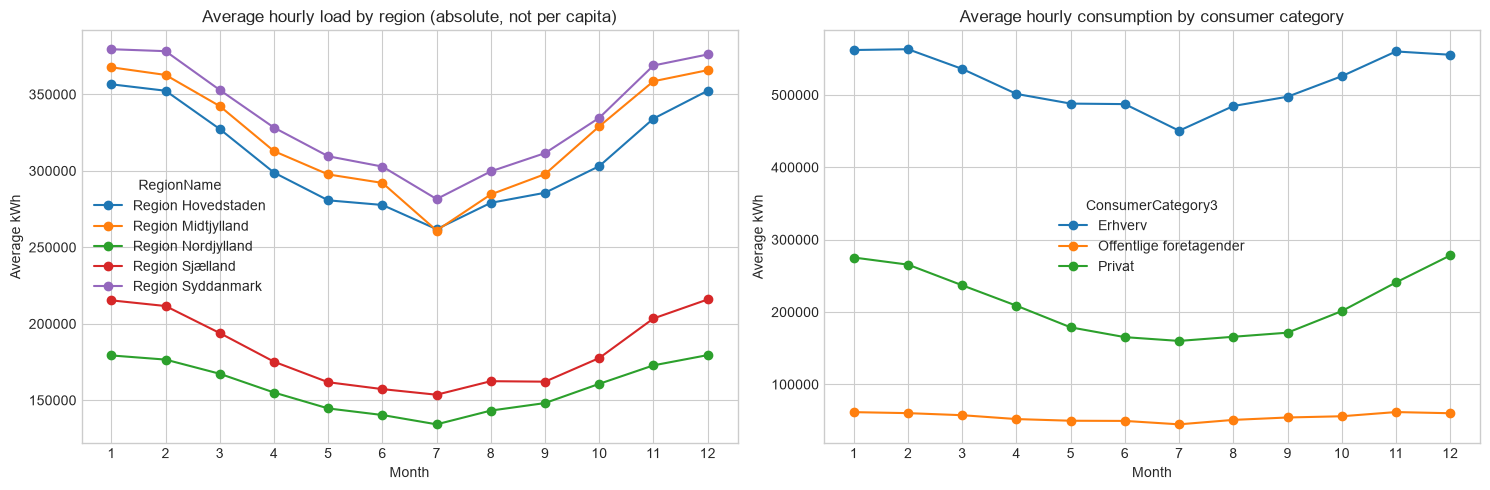

In [11]:
region_year = df.groupby(['year', 'RegionName'])['ConsumptionkWh'].sum().unstack('year')
category_year = df.groupby(['year', 'ConsumerCategory3'])['ConsumptionkWh'].sum().unstack('year')
print('Consumption by region and year')
display(region_year)
print('Consumption by category and year')
display(category_year)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
region_month = df.groupby(['month', 'RegionName'])['ConsumptionkWh'].mean().unstack('RegionName')
category_month = df.groupby(['month', 'ConsumerCategory3'])['ConsumptionkWh'].mean().unstack('ConsumerCategory3')
region_month.plot(ax=axes[0], marker='o')
category_month.plot(ax=axes[1], marker='o')
axes[0].set_title('Average hourly load by region (absolute, not per capita)')
axes[1].set_title('Average hourly consumption by consumer category')
for ax in axes:
    ax.set_xlabel('Month')
    ax.set_ylabel('Average kWh')
    ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

rows
ConsumerCategory2 ConsumerCategory3              
Erhverv           Erhverv                  219120
                  Offentlige foretagender  219120
Privat            Privat                   219120

,share_pct
ConsumerCategory3,
Erhverv,65.96
Privat,27.04
Offentlige foretagender,6.99


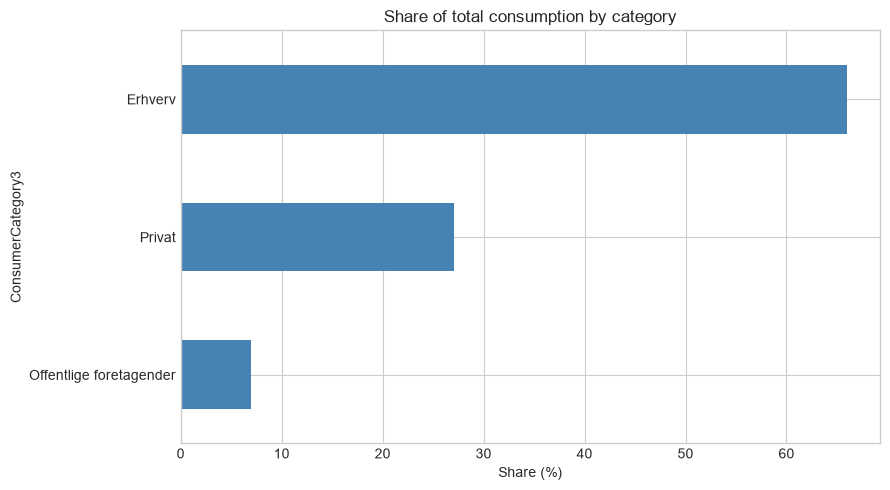

In [12]:
# Check that category 3 is consistent with category 2.
category_hierarchy = df.groupby(['ConsumerCategory2', 'ConsumerCategory3']).size()
display(category_hierarchy.to_frame('rows'))

shares = (df.groupby('ConsumerCategory3')['ConsumptionkWh'].sum()
            .div(df['ConsumptionkWh'].sum())
            .mul(100)
            .sort_values(ascending=False)
            .rename('share_pct'))
display(shares.to_frame())

fig, ax = plt.subplots(figsize=(9, 5))
shares.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('Share of total consumption by category')
ax.set_xlabel('Share (%)')
plt.tight_layout()
plt.show()

## 7. Intraday and weekday/weekend behavior

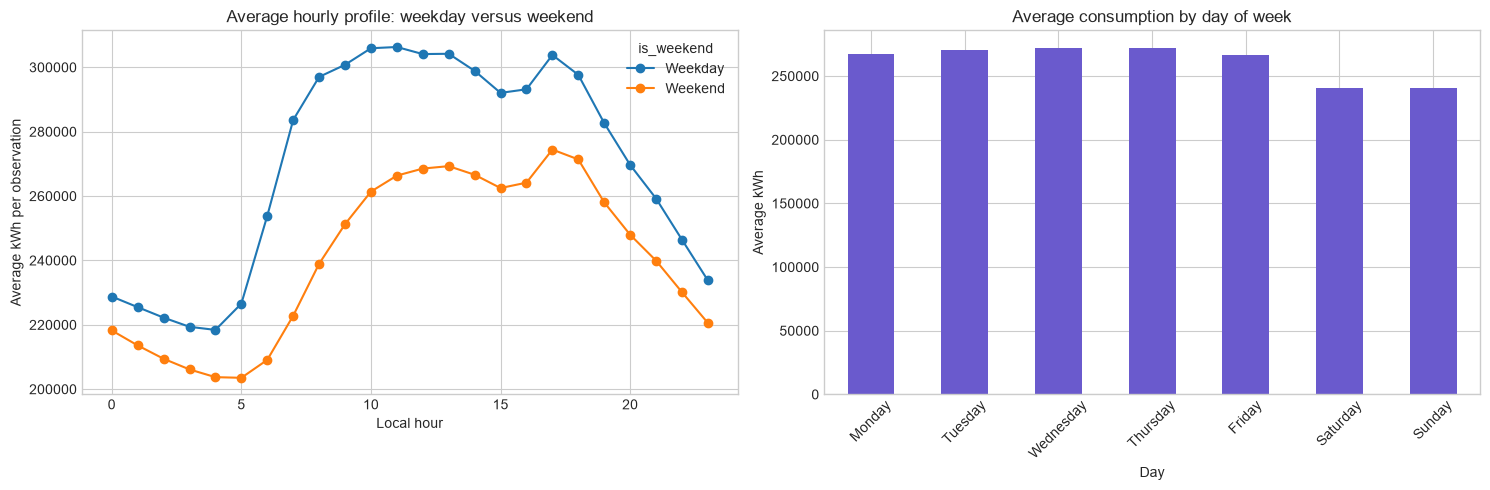

is_weekend,Weekday,Weekend
hour,,
0,"228,776.20","218,237.76"
1,"225,473.88","213,586.07"
2,"222,217.41","209,441.60"
3,"219,369.03","206,124.57"
4,"218,406.59","203,725.30"
5,"226,566.95","203,526.27"
6,"253,839.13","209,091.68"
7,"283,626.32","222,811.91"
8,"297,010.32","238,946.08"


In [13]:
hour_profile = df.groupby(['hour', 'is_weekend'])['ConsumptionkWh'].mean().unstack('is_weekend')
hour_profile = hour_profile.rename(columns={False: 'Weekday', True: 'Weekend'})
day_profile = df.groupby('day_name')['ConsumptionkWh'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
hour_profile.plot(ax=axes[0], marker='o')
day_profile.plot.bar(ax=axes[1], color='slateblue')
axes[0].set_title('Average hourly profile: weekday versus weekend')
axes[0].set_xlabel('Local hour')
axes[0].set_ylabel('Average kWh per observation')
axes[1].set_title('Average consumption by day of week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average kWh')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(hour_profile)

## 8. Distribution and outlier review

A non-negative target with a long right tail should be inspected on both the original and logarithmic scales. A high value is not automatically an error; it requires domain validation.

,ConsumptionkWh
count,"657,360.00"
mean,"261,453.58"
std,"230,741.76"
min,"15,883.71"
0.1%,"18,623.26"
1%,"21,184.82"
50%,"201,400.57"
99%,"919,737.07"
99.9%,"1,082,963.12"
max,"1,468,206.80"


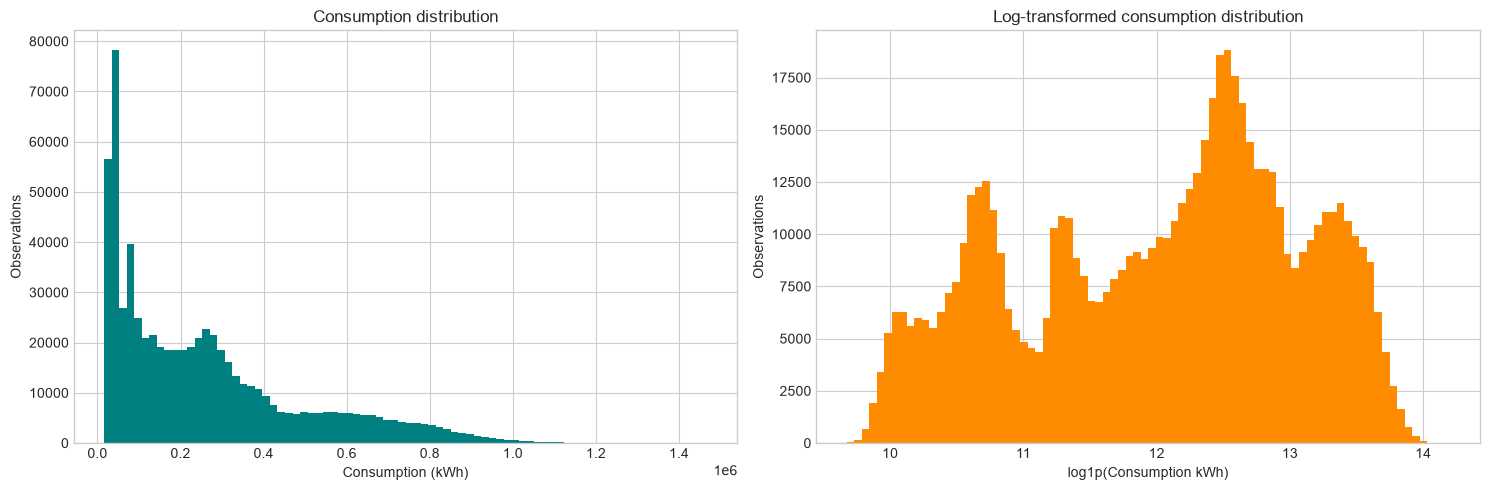

In [14]:
summary = df['ConsumptionkWh'].describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999])
display(summary.to_frame('ConsumptionkWh'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df['ConsumptionkWh'], bins=80, color='teal')
axes[0].set_title('Consumption distribution')
axes[0].set_xlabel('Consumption (kWh)')
axes[0].set_ylabel('Observations')
axes[1].hist(np.log1p(df['ConsumptionkWh']), bins=80, color='darkorange')
axes[1].set_title('Log-transformed consumption distribution')
axes[1].set_xlabel('log1p(Consumption kWh)')
axes[1].set_ylabel('Observations')
plt.tight_layout()
plt.show()

In [15]:
q1, q3 = df['ConsumptionkWh'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = df[df['ConsumptionkWh'] > upper_fence].copy()
print(f'IQR upper fence: {upper_fence:,.2f} kWh')
print(f'Potential high outliers: {len(outliers):,} ({len(outliers) / len(df):.2%})')
display(outliers.nlargest(20, 'ConsumptionkWh')[['TimeUTC', 'TimeDK', 'RegionName', 'ConsumerCategory3', 'ConsumptionkWh']])

series_sorted = df.sort_values(series_key + ['TimeUTC']).copy()
series_sorted['hourly_change_pct'] = (
    series_sorted.groupby(series_key)['ConsumptionkWh'].pct_change() * 100
)
display(series_sorted.nlargest(20, 'hourly_change_pct')[series_key + ['TimeUTC', 'ConsumptionkWh', 'hourly_change_pct']])

IQR upper fence: 816,030.51 kWh
Potential high outliers: 19,300 (2.94%)


,TimeUTC,TimeDK,RegionName,ConsumerCategory3,ConsumptionkWh
653568,2025-12-11 11:00:00,2025-12-11 12:00:00,Region Midtjylland,Erhverv,"1,468,206.80"
653577,2025-12-11 11:00:00,2025-12-11 12:00:00,Region Syddanmark,Erhverv,"1,373,094.41"
653562,2025-12-11 12:00:00,2025-12-11 13:00:00,Region Syddanmark,Erhverv,"1,317,591.57"
641643,2025-11-13 14:00:00,2025-11-13 15:00:00,Region Midtjylland,Erhverv,"1,297,128.51"
433938,2024-04-11 11:00:00,2024-04-11 13:00:00,Region Midtjylland,Erhverv,"1,283,896.20"
573258,2025-05-20 11:00:00,2025-05-20 13:00:00,Region Midtjylland,Erhverv,"1,279,149.13"
573243,2025-05-20 12:00:00,2025-05-20 14:00:00,Region Midtjylland,Erhverv,"1,275,542.43"
434283,2024-04-10 12:00:00,2024-04-10 14:00:00,Region Midtjylland,Erhverv,"1,274,305.90"
634848,2025-10-02 10:00:00,2025-10-02 12:00:00,Region Midtjylland,Erhverv,"1,274,011.11"
572508,2025-05-22 13:00:00,2025-05-22 15:00:00,Region Midtjylland,Erhverv,"1,271,837.18"


,RegionName,ConsumerCategory3,TimeUTC,ConsumptionkWh,hourly_change_pct
302658,Region Midtjylland,Erhverv,2023-04-10 03:00:00,"675,000.76",80.08
442278,Region Midtjylland,Erhverv,2024-05-19 07:00:00,"781,921.58",71.80
303618,Region Midtjylland,Erhverv,2023-04-07 11:00:00,"821,729.94",69.91
314658,Region Midtjylland,Erhverv,2023-05-07 19:00:00,"729,445.68",67.81
633588,Region Midtjylland,Erhverv,2025-10-05 22:00:00,"923,311.79",57.86
302598,Region Midtjylland,Erhverv,2023-04-10 07:00:00,"723,701.79",56.36
303858,Region Midtjylland,Erhverv,2023-04-06 19:00:00,"754,599.42",56.14
305958,Region Midtjylland,Erhverv,2023-03-31 23:00:00,"817,200.62",55.22
285723,Region Midtjylland,Erhverv,2023-03-27 05:00:00,"1,117,009.43",55.00
442248,Region Midtjylland,Erhverv,2024-05-19 09:00:00,"873,227.03",54.47


The IQR upper fence identifies potential high-consumption observations, but these are not automatically treated as errors. Valid peaks are retained because peak demand is relevant to forecasting.

## 9. Modeling readiness and leakage prevention

For forecasting, use a chronological split. 

Setup: use complete calendar years for the final forecast evaluation.

The selected split is 2021–2023 for training, 2024 for validation, and 2025 for testing (approximately 60% / 20% / 20% by rows).

1. Training: 2021–2023.
2. Validation: a late period in 2024, selected according to the forecast horizon.
3. Test: complete year 2025, kept untouched for final evaluation.
4. Use `TimeUTC` for ordering and split boundaries.
5. Fit scalers, encoders, and imputation rules on training data only.
6. Do not use full-period annual/monthly totals as row-level predictors.

In [16]:
# Final chronological split: 2021–2023 train, 2024 validation, 2025 test.
train_end = pd.Timestamp('2023-12-31 23:00:00')
validation_end = pd.Timestamp('2024-12-31 23:00:00')
train = df[df['TimeUTC'] <= train_end].copy()
validation = df[(df['TimeUTC'] > train_end) & (df['TimeUTC'] <= validation_end)].copy()
test = df[df['TimeUTC'] > validation_end].copy()

split_summary = pd.DataFrame({
    'rows': [len(train), len(validation), len(test)],
    'start_utc': [train['TimeUTC'].min(), validation['TimeUTC'].min(), test['TimeUTC'].min()],
    'end_utc': [train['TimeUTC'].max(), validation['TimeUTC'].max(), test['TimeUTC'].max()],
}, index=['train', 'validation', 'test'])
display(split_summary)
print('Approximate split by calendar years: 60% train, 20% validation, 20% test.')
assert train['TimeUTC'].max() < validation['TimeUTC'].min()
assert validation['TimeUTC'].max() < test['TimeUTC'].min()

,rows,start_utc,end_utc
train,394215,2020-12-31 23:00:00,2023-12-31 23:00:00
validation,131760,2024-01-01 00:00:00,2024-12-31 23:00:00
test,131385,2025-01-01 00:00:00,2025-12-31 22:00:00


Approximate split by calendar years: 60% train, 20% validation, 20% test.


## 10. Findings and next actions

After running the cells, record the domain interpretation here. At minimum, confirm:

- whether the `Region Sjælland` label is corrected upstream;
- whether the highest values are legitimate events;
- which regions/categories drive the year-over-year changes;
- whether weekday/weekend and hourly patterns are expected;
- the forecast horizon and final chronological train/validation/test boundaries;
- the treatment of DST and whether UTC or local time is used for features.

The dataset currently passes the basic completeness checks in this notebook, but production preprocessing should move the label repair and timestamp validation from this notebook into the dataset-building pipeline.